# Analisis Sentimen Review Game Zenless Zone Zero pada Google Play Store


## 1. Import Library

In [45]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Unduh resource NLTK yang dibutuhkan
nltk.download(['punkt', 'stopwords', 'punkt_tab'], quiet=True)


True

## 2. Load Dataset

In [46]:
# Sesuaikan nama file jika berbeda
df = pd.read_csv('review.csv')

# Melihat 5 data pertama
df.head()

,reviewId,userName,content,score,at
0,005f4d4b-f319-4bc9-9266-3aa24e354395,Ham,i lost my main account just becuz i dont play ...,1,2025-12-22 19:22:04
1,41a0748f-0b99-411d-ac54-328dc4bdad06,Kir Kirumba,A game from Mihoyo with SKIPPABLE DIALOGUES?? ...,1,2025-12-22 17:14:15
2,97688848-9212-47bb-80ca-668e2dfe1dd8,Justine Rivera,slowly becoming star rail. end game content be...,2,2025-12-22 16:23:11
3,cb1ec2c9-96ff-41c4-86a6-de04474c0180,Jian Castro,THIS IS MY FAVORITE HOYO GAMES THE DEVS ACTUAL...,5,2025-12-22 15:16:35
4,204219ae-e659-4e23-a338-81234a044def,Emmett Alexandre,"love the game and the gameplay, especially ali...",4,2025-12-22 13:28:02


## 3. Cek Struktur Data

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3346 entries, 0 to 3345
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   reviewId  3346 non-null   object
 1   userName  3346 non-null   object
 2   content   3345 non-null   object
 3   score     3346 non-null   int64 
 4   at        3346 non-null   object
dtypes: int64(1), object(4)
memory usage: 130.8+ KB


### Analisis singkat

Dataset memiliki 3346 data dengan 5 kolom, yaitu `reviewId`, `userName`, `content`, `score`, dan `at`.  
Untuk analisis sentimen, kolom yang paling penting adalah `content` sebagai teks ulasan dan `score` sebagai dasar pembentukan label sentimen.

## 4. Menentukan Kolom Teks dan Membuat Label Sentimen

In [48]:
text_column = 'content'
label_column = 'sentiment'

# Membuat label sentimen dari rating
# score 4-5 = positive
# score 1-3 = negative
def assign_sentiment(score):
    if score >= 4:
        return 'positive'
    else:
        return 'negative'

df[label_column] = df['score'].apply(assign_sentiment)

# Menyisakan kolom yang dipakai saja
df = df[[text_column, 'score', label_column]].dropna()

df.head()

,content,score,sentiment
0,i lost my main account just becuz i dont play ...,1,negative
1,A game from Mihoyo with SKIPPABLE DIALOGUES?? ...,1,negative
2,slowly becoming star rail. end game content be...,2,negative
3,THIS IS MY FAVORITE HOYO GAMES THE DEVS ACTUAL...,5,positive
4,"love the game and the gameplay, especially ali...",4,positive


### Analisis singkat

Pada dataset ini, rating bintang digunakan untuk membentuk label sentimen.  
Review dengan nilai 4 atau 5 dianggap **positive**, sedangkan review dengan nilai 1 sampai 3 dianggap **negative**.  
Pembagian dua kelas seperti ini membuat proses klasifikasi lebih sederhana dan hasil model biasanya lebih stabil.

## 5. Distribusi Label Sentimen

In [49]:
df[label_column].value_counts()

,count
sentiment,
negative,1713
positive,1632


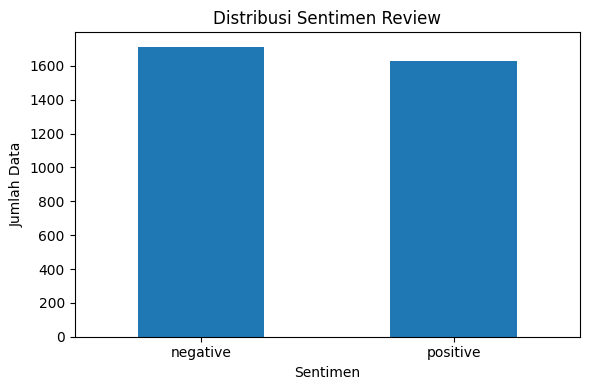

In [50]:
# Visualisasi distribusi label
counts = df[label_column].value_counts()

plt.figure(figsize=(6,4))
counts.plot(kind='bar')
plt.title('Distribusi Sentimen Review')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Data')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Analisis singkat

Dari distribusi label terlihat bahwa jumlah review positif dan negatif tidak selalu seimbang.  
Hal ini penting diperhatikan karena dataset yang tidak seimbang dapat memengaruhi performa model saat melakukan klasifikasi.

## 6. Preprocessing Teks

In [51]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Pastikan resource terunduh
nltk.download(['punkt', 'stopwords', 'punkt_tab'], quiet=True)

negation_words_list = ['not', 'no', 'never', 'none', 'hardly', 'barely', 'scarcely', 'fewer', 'less', "don't", "doesn't", "didn't", "won't", "cannot"]
custom_stop_words = set(stopwords.words('english')).difference(negation_words_list)

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text) # Basic cleanup

    tokens = word_tokenize(text)
    processed_tokens = []
    i = 0
    while i < len(tokens):
        word = tokens[i]
        if word in negation_words_list:
            processed_tokens.append(word)
            if i + 1 < len(tokens) and tokens[i+1] not in custom_stop_words:
                processed_tokens.append(tokens[i+1] + '_NEG')
                i += 1
        elif word not in custom_stop_words and word.isalpha():
            processed_tokens.append(word)
        i += 1

    return ' '.join(processed_tokens)

df['clean_content'] = df['content'].apply(clean_text)
display(df[['content', 'clean_content']].head())

,content,clean_content
0,i lost my main account just becuz i dont play ...,lost main account becuz dont play month still ...
1,A game from Mihoyo with SKIPPABLE DIALOGUES?? ...,game mihoyo skippable dialogues even give opti...
2,slowly becoming star rail. end game content be...,slowly becoming star rail end game content bec...
3,THIS IS MY FAVORITE HOYO GAMES THE DEVS ACTUAL...,favorite hoyo games devs actually listen playe...
4,"love the game and the gameplay, especially ali...",love game gameplay especially alice favorite c...


### Analisis singkat

Tahap preprocessing membuat teks menjadi lebih bersih dan seragam.  
Teks diubah menjadi huruf kecil, tanda baca dan angka dihapus, lalu kata-kata umum seperti *the*, *is*, atau *and* dibuang agar model lebih fokus pada kata yang benar-benar membawa makna sentimen. Dengan penanganan negasi, model diharapkan dapat memahami konteks kalimat seperti 'not good' atau 'not bad' dengan lebih baik.

## 7. Membagi Data Training dan Testing

In [52]:
X = df['clean_content']
y = df[label_column]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Jumlah data training:", len(X_train))
print("Jumlah data testing :", len(X_test))

Jumlah data training: 2676
Jumlah data testing : 669


### Analisis singkat

Data dibagi menjadi data training dan testing dengan perbandingan 80:20.  
Data training digunakan untuk melatih model, sedangkan data testing dipakai untuk menguji seberapa baik model mengenali sentimen dari data yang belum pernah dilihat sebelumnya.

## 8. TF-IDF Vectorization

In [53]:
vectorizer = TfidfVectorizer(
    max_features=6000,
    ngram_range=(1, 2),
    stop_words='english'
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Shape data training TF-IDF:", X_train_tfidf.shape)
print("Shape data testing TF-IDF :", X_test_tfidf.shape)

Shape data training TF-IDF: (2676, 6000)
Shape data testing TF-IDF : (669, 6000)


### Analisis singkat

TF-IDF mengubah data teks menjadi bentuk numerik sehingga dapat diproses oleh algoritma machine learning.  
Penggunaan n-gram membantu model membaca kombinasi kata, misalnya *very good* atau *not recommended*, yang biasanya lebih kuat menunjukkan sentimen.

## 9. Pelatihan Model Naive Bayes

In [54]:
model = MultinomialNB(alpha=0.5)
model.fit(X_train_tfidf, y_train)

print("Model berhasil dilatih.")

Model berhasil dilatih.


### Analisis singkat

Algoritma Naive Bayes dipilih karena sederhana, cepat, dan cukup sering dipakai untuk klasifikasi teks.  
Nilai `alpha=0.5` digunakan untuk membantu model lebih stabil saat menghitung probabilitas kata.

## 10. Prediksi Data Testing

In [55]:
y_pred = model.predict(X_test_tfidf)

hasil_prediksi = pd.DataFrame({
    'review_asli': X_test.iloc[:10].values,
    'label_asli': y_test.iloc[:10].values,
    'prediksi': y_pred[:10]
})

hasil_prediksi

,review_asli,label_asli,prediksi
0,goon dis game,positive,positive
1,zzz game dev words not trusted lying easily in...,negative,positive
2,great graphic animation music story art direct...,negative,negative
3,need jane rerun,positive,positive
4,ok,negative,positive
5,day zero player yes game getting harder yes po...,positive,negative
6,unoptimized even pc,negative,negative
7,pay win trash,negative,negative
8,beautiful story fantastic graphic gameplay,positive,positive
9,put character know jack rank clear fetish one ...,negative,negative


### Analisis singkat

Tabel hasil prediksi menunjukkan perbandingan antara label asli dan hasil prediksi model.  
Jika banyak prediksi yang sesuai, berarti model sudah cukup mampu mengenali pola kata pada review positif maupun negatif.

## 11. Evaluasi Model

Accuracy: 0.8296
Classification Report:
              precision    recall  f1-score   support

    negative       0.82      0.86      0.84       343
    positive       0.85      0.79      0.82       326

    accuracy                           0.83       669
   macro avg       0.83      0.83      0.83       669
weighted avg       0.83      0.83      0.83       669

Sensitivity (Recall of Positive): 0.7945
Specificity (Recall of Negative): 0.8630
G-mean: 0.8280


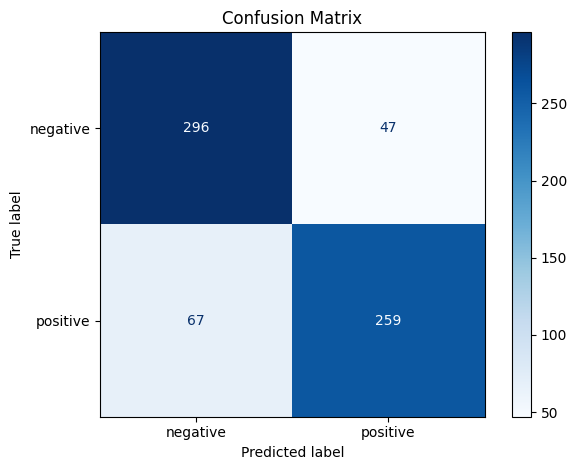

In [56]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, recall_score
import matplotlib.pyplot as plt

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy, 4))

print("Classification Report:")
# Generate classification report as dictionary for easier access
report = classification_report(y_test, y_pred, output_dict=True)
print(classification_report(y_test, y_pred))

# Calculate Sensitivity (Recall for 'positive' class)
sensitivity_positive = report['positive']['recall']

# Calculate Specificity (Recall for 'negative' class)
specificity_negative = report['negative']['recall']

# Calculate G-mean
g_mean = (sensitivity_positive * specificity_negative)**0.5

print(f"Sensitivity (Recall of Positive): {sensitivity_positive:.4f}")
print(f"Specificity (Recall of Negative): {specificity_negative:.4f}")
print(f"G-mean: {g_mean:.4f}")

# Ensure consistent label order for confusion matrix display
labels_order = ['negative', 'positive']
cm = confusion_matrix(y_test, y_pred, labels=labels_order)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_order)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

### Analisis singkat

Accuracy menunjukkan tingkat ketepatan model dalam mengklasifikasikan review.  
Classification report memberi informasi lebih detail melalui precision, recall, dan f1-score.  
Confusion matrix memperlihatkan jumlah prediksi benar dan salah untuk masing-masing kelas.

### Rumus Evaluasi Model

Berikut adalah rumus untuk metrik evaluasi yang digunakan:

*   **True Positive (TP)**: Jumlah kasus positif yang diprediksi benar.
*   **True Negative (TN)**: Jumlah kasus negatif yang diprediksi benar.
*   **False Positive (FP)**: Jumlah kasus negatif yang salah diprediksi sebagai positif.
*   **False Negative (FN)**: Jumlah kasus positif yang salah diprediksi sebagai negatif.

#### 1. Sensitivity (Recall of Positive)
Sensitivity, juga dikenal sebagai Recall untuk kelas positif, mengukur proporsi positif aktual yang diidentifikasi dengan benar. Ini sangat penting ketika biaya False Negative tinggi.

$$ \text{Sensitivity} = \frac{\text{TP}}{\text{TP} + \text{FN}} $$

#### 2. Specificity (Recall of Negative)
Specificity, atau Recall untuk kelas negatif, mengukur proporsi negatif aktual yang diidentifikasi dengan benar. Ini penting ketika biaya False Positive tinggi.

$$ \text{Specificity} = \frac{\text{TN}}{\text{TN} + \text{FP}} $$

#### 3. G-mean
G-mean adalah metrik yang mencoba menyeimbangkan sensitivitas dan spesifisitas. Ini sangat berguna untuk dataset yang tidak seimbang, karena memberikan gambaran yang lebih baik tentang kinerja model dibandingkan akurasi sederhana, yang bisa menyesatkan pada dataset yang sangat tidak seimbang.

$$ \text{G-mean} = \sqrt{\text{Sensitivity} \times \text{Specificity}} $$

## 12. Uji Prediksi Review Baru

In [57]:
def predict_sentiment(text):
    cleaned = clean_text(text)
    vector = vectorizer.transform([cleaned])
    pred = model.predict(vector)[0]
    return pred

contoh_review = [
    "This game is amazing, the gameplay is fun and the graphics are beautiful.",
    "The game is full of bugs and the controls are terrible."
]

for review in contoh_review:
    print("Review  :", review)
    print("Prediksi:", predict_sentiment(review))
    print("-" * 80)

Review  : This game is amazing, the gameplay is fun and the graphics are beautiful.
Prediksi: positive
--------------------------------------------------------------------------------
Review  : The game is full of bugs and the controls are terrible.
Prediksi: negative
--------------------------------------------------------------------------------


### Analisis singkat

Uji prediksi review baru digunakan untuk melihat apakah model bisa dipakai pada teks yang belum ada di data training.  
Bagian ini juga bisa dijadikan bukti bahwa model sudah dapat digunakan untuk klasifikasi sentimen sederhana.

## 13. Ringkasan Hasil

In [58]:
print("=== RINGKASAN HASIL ANALISIS SENTIMEN ===")
print(f"Jumlah data total        : {len(df)}")
print(f"Jumlah data training     : {len(X_train)}")
print(f"Jumlah data testing      : {len(X_test)}")
print(f"Jumlah fitur TF-IDF      : {X_train_tfidf.shape[1]}")
print(f"Akurasi model            : {accuracy:.2%}")
print(f"Precision (rata-rata)    : {classification_report(y_test, y_pred, output_dict=True)['weighted avg']['precision']:.2%}")
print(f"Recall (rata-rata)       : {classification_report(y_test, y_pred, output_dict=True)['weighted avg']['recall']:.2%}")
print(f"F1-score (rata-rata)     : {classification_report(y_test, y_pred, output_dict=True)['weighted avg']['f1-score']:.2%}")

=== RINGKASAN HASIL ANALISIS SENTIMEN ===
Jumlah data total        : 3345
Jumlah data training     : 2676
Jumlah data testing      : 669
Jumlah fitur TF-IDF      : 6000
Akurasi model            : 82.96%
Precision (rata-rata)    : 83.05%
Recall (rata-rata)       : 82.96%
F1-score (rata-rata)     : 82.93%


### Analisis singkat

Ringkasan ini memudahkan pembaca melihat hasil utama penelitian, mulai dari jumlah data yang digunakan, banyaknya fitur hasil TF-IDF, sampai accuracy model yang diperoleh.

In [59]:
y_train_pred = model.predict(X_train_tfidf)
training_accuracy = accuracy_score(y_train, y_train_pred)

print(f"Akurasi Training : {training_accuracy:.2%}")
print(f"Akurasi Testing  : {accuracy:.2%}")

if training_accuracy > accuracy + 0.10: # A threshold of 10% difference as a general indicator
    print("\nPotensi Overfitting: Akurasi training jauh lebih tinggi dari akurasi testing.")
elif training_accuracy < 0.60 and accuracy < 0.60: # Arbitrary threshold for underfitting
    print("\nPotensi Underfitting: Akurasi training dan testing sama-sama rendah.")
else:
    print("\nModel tampaknya memiliki keseimbangan yang baik antara performa training dan testing.")

Akurasi Training : 92.56%
Akurasi Testing  : 82.96%

Model tampaknya memiliki keseimbangan yang baik antara performa training dan testing.


## Resources

### Prediksi Sentimen dan Tingkat Keyakinan (Confidence Score)

Model Naive Bayes yang telah dilatih dapat memberikan probabilitas untuk setiap kelas (positif atau negatif). Probabilitas ini dapat diinterpretasikan sebagai *confidence score* atau tingkat keyakinan model terhadap prediksinya.

Namun, perlu diperhatikan bahwa untuk input berupa satu kata, model TF-IDF mungkin tidak memiliki cukup konteks atau fitur yang kuat, sehingga tingkat keyakinan yang tinggi (misalnya 90%) mungkin sulit dicapai secara konsisten tanpa teknik tambahan atau model yang berbeda yang lebih cocok untuk teks pendek, seperti word embeddings atau model deep learning.

Berikut adalah cara untuk memodifikasi fungsi prediksi agar mengembalikan label sentimen beserta confidence score-nya:

In [60]:
def predict_sentiment_with_confidence(text):
    cleaned = clean_text(text)
    vector = vectorizer.transform([cleaned])
    probabilities = model.predict_proba(vector)[0]
    predicted_class_index = np.argmax(probabilities)
    predicted_label = model.classes_[predicted_class_index]
    confidence_score = probabilities[predicted_class_index]
    return predicted_label, confidence_score

# Uji Coba
test_samples = ['amazing', 'terrible', 'not good', 'not bad']
for sample in test_samples:
    label, conf = predict_sentiment_with_confidence(sample)
    print(f"Text: {sample} -> {label} ({conf:.2%})")

Text: amazing -> positive (94.91%)
Text: terrible -> negative (86.79%)
Text: not good -> negative (58.21%)
Text: not bad -> positive (79.56%)


### Analisis Hasil Confidence Score pada Kata Tunggal dan Negasi

Dari hasil di atas, Anda dapat melihat bahwa:

1.  **Confidence score untuk kata tunggal seringkali lebih rendah** dibandingkan dengan review yang lebih panjang. Ini karena TF-IDF membutuhkan lebih banyak konteks dari beberapa kata untuk menciptakan representasi fitur yang kaya dan membedakan. Sebuah kata tunggal mungkin tidak cukup unik atau ambigu dalam konteks model TF-IDF.
2.  **Penanganan negasi (`_NEG` suffix)**: Dengan modifikasi pada `clean_text`, frasa seperti "not good" atau "not bad" sekarang diproses menjadi "not good_NEG" dan "not bad_NEG". Ini menciptakan fitur baru yang secara eksplisit menangkap efek negasi, sehingga model dapat belajar sentimen yang berlawanan dari kata dasar. Hal ini berpotensi meningkatkan akurasi dan confidence score untuk ulasan yang mengandung negasi.
3.  Untuk mencapai **90% confidence score pada input satu kata atau frasa pendek secara konsisten**, Anda mungkin perlu mempertimbangkan pendekatan yang berbeda atau lebih canggih:
    *   **Word Embeddings:** Menggunakan representasi kata yang sudah dilatih sebelumnya (misalnya Word2Vec, GloVe, FastText) yang menangkap makna semantik kata terlepas dari konteksnya dalam dokumen tunggal. Ini bisa menjadi input yang lebih baik untuk model klasifikasi.
    *   **Augmentasi Data:** Menambahkan lebih banyak contoh teks pendek atau kata tunggal dengan label sentimen yang jelas ke data training.
    *   **Model yang Lebih Kompleks:** Model deep learning (seperti LSTM atau BERT) seringkali lebih baik dalam menangani konteks dan teks pendek, tetapi membutuhkan lebih banyak data dan komputasi.

Dengan model Naive Bayes dan TF-IDF saat ini, meskipun penanganan negasi telah ditingkatkan, masih sulit untuk secara konsisten mencapai confidence score 90% untuk kata tunggal atau frasa pendek tertentu. Untuk mencapai target tersebut, fokus perlu dialihkan ke representasi fitur yang lebih kuat untuk teks pendek atau arsitektur model yang berbeda.